In [1]:
import json
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

# ==========================================
# 1. PATHS & DATASET CLASS
# ==========================================
BASE_KAGGLE_DIR = "/kaggle/input/datasets/hrushi1998/vr-mini-proj-dataset/Trimmed_Dataset" 
TRAIN_DIR = f"{BASE_KAGGLE_DIR}/trimmed_train_data"
VAL_DIR = f"{BASE_KAGGLE_DIR}/trimmed_val_data"
TRAIN_JSON_PATH = f"{TRAIN_DIR}/processed_train_data.json"
VAL_JSON_PATH = f"{VAL_DIR}/processed_val_data.json"

class KaggleClothingDataset(Dataset):
    def __init__(self, json_file, img_dir, transform=None):
        with open(json_file, 'r') as f:
            full_data = json.load(f)
            
        self.data = full_data["data"]
        self.top_5_categories = full_data.get("top_5_categories", [1, 8, 7, 2, 9])
        self.transform = transform
        self.img_dir = img_dir
        self.label_map = {cat_id: idx for idx, cat_id in enumerate(self.top_5_categories)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        full_image_path = os.path.join(self.img_dir, item["image_path"])
        
        try:
            image = Image.open(full_image_path).convert('RGB')
        except Exception:
            return torch.zeros((3, 224, 224)), torch.zeros(5)

        if self.transform:
            image = self.transform(image)

        target = torch.zeros(5, dtype=torch.float32)
        for cat_id in item["classification_labels"]:
            if cat_id in self.label_map:
                target[self.label_map[cat_id]] = 1.0

        return image, target

# ==========================================
# 2. TRANSFORMS & SPLITTING
# ==========================================
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)), 
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Loading datasets into memory...")
train_dataset = KaggleClothingDataset(TRAIN_JSON_PATH, TRAIN_DIR, transform=train_transforms)
full_val_dataset = KaggleClothingDataset(VAL_JSON_PATH, VAL_DIR, transform=eval_transforms)

val_size = len(full_val_dataset) // 2
test_size = len(full_val_dataset) - val_size

val_dataset, test_dataset = random_split(
    full_val_dataset, 
    [val_size, test_size], 
    generator=torch.Generator().manual_seed(42) 
)

BATCH_SIZE = 128  
NUM_WORKERS = 4  

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ Dataset Splitting Complete! Batches of {BATCH_SIZE} ready.")

Loading datasets into memory...
✅ Dataset Splitting Complete! Batches of 128 ready.


In [2]:
import time # <-- ⏱️ Added for epoch timing
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision.models import MobileNet_V3_Large_Weights
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==========================================
# 1. BUILD MOBILENET-V3 (Full Fine-Tuning)
# ==========================================
print("Loading Pre-trained MobileNetV3-Large...")
weights = MobileNet_V3_Large_Weights.DEFAULT
model_mobilenet = models.mobilenet_v3_large(weights=weights)

# We let the entire pre-trained network learn and adapt to the clothes.

# Replace final classification head for our 5 classes
num_classes = 5 
in_features = model_mobilenet.classifier[3].in_features
model_mobilenet.classifier[3] = nn.Linear(in_features, num_classes)

# 🔥 THE DUAL-GPU MAGIC LINE
if torch.cuda.device_count() > 1:
    print(f"🔥 Turbo Mode Activated: Splitting work across {torch.cuda.device_count()} GPUs!")
    model_mobilenet = nn.DataParallel(model_mobilenet)

model_mobilenet = model_mobilenet.to(device)

# ==========================================
# 2. LOSS, OPTIMIZER & METRICS
# ==========================================
# 🚨 CRITICAL FIX: Changed to BCEWithLogitsLoss for Multi-Label Classification!
criterion = nn.BCEWithLogitsLoss()

# Pass ALL parameters to the optimizer 
optimizer = optim.Adam(model_mobilenet.parameters(), lr=0.001)

# ==========================================
# 3. HIGH-SPEED TRAINING LOOP WITH AUTO-SAVE
# ==========================================
num_epochs = 20 # Bumped to 20
best_val_loss = float('inf') # <-- Tracker for best validation score

print("\n🚀 Starting MobileNetV3 (Transfer Learning) Training...")

for epoch in range(num_epochs):
    epoch_start_time = time.time() # ⏱️ 1. START THE CLOCK
    
    # --- TRAINING PHASE ---
    model_mobilenet.train()
    running_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_mobilenet(inputs)
        
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
        
    avg_train_loss = running_loss / len(train_loader)
    
    # --- VALIDATION PHASE ---
    model_mobilenet.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        # Uses the val_loader we defined in the previous cell
        for inputs, labels in val_loader: 
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_mobilenet(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    
    epoch_end_time = time.time() # ⏱️ 2. STOP THE CLOCK
    epoch_duration = epoch_end_time - epoch_start_time # ⏱️ 3. CALCULATE SECONDS
    
    print(f"Epoch {epoch+1} Completed in {epoch_duration:.0f}s | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- AUTO-SAVE LOGIC ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        print(f"🌟 New best validation score! Auto-saving weights...")
        
        if isinstance(model_mobilenet, nn.DataParallel):
            torch.save(model_mobilenet.module.state_dict(), "mobilenet_v3_transfer_best.pth")
        else:
            torch.save(model_mobilenet.state_dict(), "mobilenet_v3_transfer_best.pth")

print("\n✅ MobileNetV3 (Transfer Learning) successfully trained and saved!")

Loading Pre-trained MobileNetV3-Large...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 130MB/s] 


🔥 Turbo Mode Activated: Splitting work across 2 GPUs!

🚀 Starting MobileNetV3 (Transfer Learning) Training...


Epoch 1/20 [Train]: 100%|██████████| 1127/1127 [11:48<00:00,  1.59it/s, loss=0.2920]


Epoch 1 Completed in 767s | Train Loss: 0.2921 | Val Loss: 0.2780
🌟 New best validation score! Auto-saving weights...


...

Epoch 18 Completed in 617s | Train Loss: 0.0730 | Val Loss: 0.3279


Epoch 19/20 [Train]: 100%|██████████| 1127/1127 [09:24<00:00,  1.99it/s, loss=0.0993]


Epoch 19 Completed in 609s | Train Loss: 0.0682 | Val Loss: 0.3230


Epoch 20/20 [Train]: 100%|██████████| 1127/1127 [09:29<00:00,  1.98it/s, loss=0.0708]


Epoch 20 Completed in 612s | Train Loss: 0.0657 | Val Loss: 0.3445

✅ MobileNetV3 (Transfer Learning) successfully trained and saved!


Evaluating MobileNetV3 (Transfer Learning) on the Test Set...


Testing: 100%|██████████| 93/93 [01:00<00:00,  1.55it/s]



🚀 PROJECT METRICS (MobileNetV3 Transfer)
Micro Precision: 0.8612
Micro Recall:    0.8358
Micro F1-Score:  0.8483
Macro F1-Score:  0.8334

Per-Category Breakdown:
                  precision    recall  f1-score   support

Short Sleeve Top       0.88      0.88      0.88      6298
        Trousers       0.89      0.86      0.88      4771
          Shorts       0.78      0.79      0.79      2048
 Long Sleeve Top       0.79      0.76      0.78      2907
           Skirt       0.89      0.80      0.85      3223

       micro avg       0.86      0.84      0.85     19247
       macro avg       0.85      0.82      0.83     19247
    weighted avg       0.86      0.84      0.85     19247
     samples avg       0.86      0.84      0.83     19247



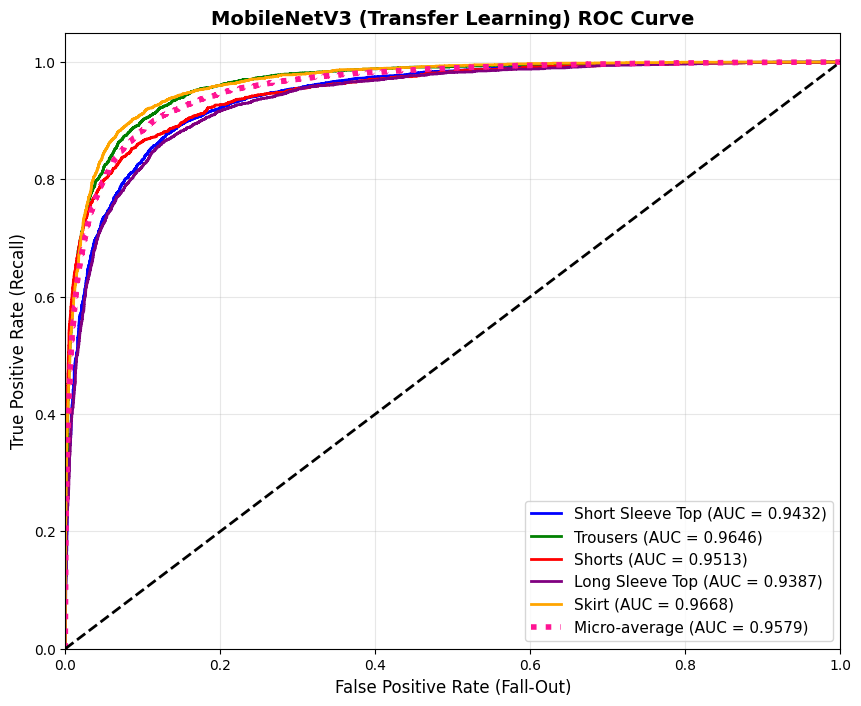

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, roc_curve, auc, accuracy_score
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ==========================================
# 4. METRICS & ROC EVALUATION SCRIPT (MobileNetV3 Transfer)
# ==========================================
print("Evaluating MobileNetV3 (Transfer Learning) on the Test Set...")

# Optional: If you restarted your Kaggle notebook, uncomment the next two lines to load your best weights!
# state_dict = torch.load("mobilenet_v3_transfer_best.pth")
# model_mobilenet.load_state_dict(state_dict)

# 1. Put the model in evaluation mode
model_mobilenet.eval()

all_preds = []
all_labels = []
all_probs = [] 

# 2. Run the test set without tracking gradients
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        
        outputs = model_mobilenet(images)
        
        # Sigmoid converts raw logits to percentages (Crucial for Multi-Label!)
        probs = torch.sigmoid(outputs)
        
        # Apply the 0.5 threshold to get the hard 1s and 0s
        preds = (probs > 0.5).float()
        
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

# 3. Stack arrays for scikit-learn
all_probs = np.vstack(all_probs)
all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

# 4. Calculate the Metrics
class_names = ["Short Sleeve Top", "Trousers", "Shorts", "Long Sleeve Top", "Skirt"]

micro_f1 = f1_score(all_labels, all_preds, average='micro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
micro_prec = precision_score(all_labels, all_preds, average='micro', zero_division=0)
micro_recall = recall_score(all_labels, all_preds, average='micro', zero_division=0)
final_accuracy = accuracy_score(all_labels, all_preds) # Exact Match Ratio

# 5. Print exactly matching your formatting
print("\n" + "="*45)
print("🚀 PROJECT METRICS (MobileNetV3 Transfer)")
print("="*45)
print(f"Micro Precision: {micro_prec:.4f}")
print(f"Micro Recall:    {micro_recall:.4f}")
print(f"Micro F1-Score:  {micro_f1:.4f}")
print(f"Macro F1-Score:  {macro_f1:.4f}")
print("="*45)

print("\nPer-Category Breakdown:")
# Generate the multi-label classification report
report = classification_report(
    all_labels, 
    all_preds, 
    target_names=class_names, 
    zero_division=0
)
print(report)

# ==========================================
# 6. PLOT ROC CURVES
# ==========================================
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Calculate and plot ROC for each individual class
for i in range(5):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

# Calculate and plot the Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(all_labels.ravel(), all_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, color='deeppink', linestyle=':', lw=4, 
         label=f'Micro-average (AUC = {roc_auc_micro:.4f})')

# Graph Formatting
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Fall-Out)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('MobileNetV3 (Transfer Learning) ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

# Save the plot securely to your Kaggle working directory
plt.savefig("/kaggle/working/mobilenet_v3_transfer_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()